In [1]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import os

In [2]:
EDGE_FILE = "/content/drive/MyDrive/SN-HW2/Wiki-Vote.txt"

edges = []
with open(EDGE_FILE, "r") as f:
    for line in f:
        if line.startswith("#"):
            continue
        u, v = line.strip().split()
        edges.append((int(u), int(v)))

G = nx.DiGraph()
G.add_edges_from(edges)

print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())

Nodes: 7115
Edges: 103689



Top-10 Authority (saved: a_top10_authority.csv)


,node,authority_score,rank_authority
905,2398,0.002580,1
326,4037,0.002573,2
2,3352,0.002328,3
286,1549,0.002304,4
432,762,0.002256,5
1005,3089,0.002253,6
247,1297,0.002250,7
699,2565,0.002224,8
409,15,0.002202,9
711,2625,0.002198,10



Top-10 PageRank (saved: a_top10_pagerank.csv)


,node,pagerank_score,rank_pagerank
326,4037,0.004613,1
409,15,0.003681,2
1332,6634,0.003525,3
711,2625,0.003286,4
905,2398,0.002605,5
686,2470,0.002530,6
656,2237,0.002505,7
1141,4191,0.002266,8
1261,7553,0.002170,9
3,5254,0.002150,10


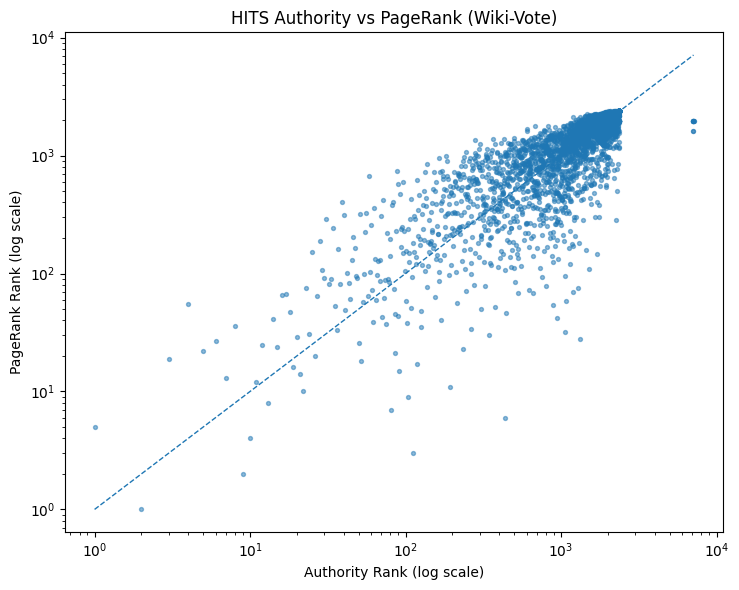

In [3]:
hubs, authorities = nx.hits(G, max_iter=1000, normalized=True)

auth_df = pd.DataFrame({
    "node": authorities.keys(),
    "authority_score": authorities.values()
})

auth_df["rank_authority"] = auth_df["authority_score"].rank(
    ascending=False, method="min"
).astype(int)


pagerank = nx.pagerank(G, alpha=0.85)

pr_df = pd.DataFrame({
    "node": pagerank.keys(),
    "pagerank_score": pagerank.values()
})

pr_df["rank_pagerank"] = pr_df["pagerank_score"].rank(
    ascending=False, method="min"
).astype(int)


merged = auth_df.merge(pr_df, on="node", how="inner")


OUT_DIR = "/content/drive/MyDrive/SN-HW2/"
os.makedirs(OUT_DIR, exist_ok=True)

top10_auth = merged.sort_values("rank_authority").head(10)[
    ["node", "authority_score", "rank_authority"]
]
top10_pr = merged.sort_values("rank_pagerank").head(10)[
    ["node", "pagerank_score", "rank_pagerank"]
]

top10_auth.to_csv(os.path.join(OUT_DIR, "a_top10_authority.csv"), index=False)
top10_pr.to_csv(os.path.join(OUT_DIR, "a_top10_pagerank.csv"), index=False)

print("\nTop-10 Authority (saved: a_top10_authority.csv)")
display(top10_auth)

print("\nTop-10 PageRank (saved: a_top10_pagerank.csv)")
display(top10_pr)


plt.figure(figsize=(7.5, 6))
plt.scatter(
    merged["rank_authority"],
    merged["rank_pagerank"],
    s=8,
    alpha=0.5
)

plt.xscale("log")
plt.yscale("log")

plt.xlabel("Authority Rank (log scale)")
plt.ylabel("PageRank Rank (log scale)")
plt.title("HITS Authority vs PageRank (Wiki-Vote)")

max_rank = max(merged["rank_authority"].max(), merged["rank_pagerank"].max())
plt.plot([1, max_rank], [1, max_rank], linestyle="--", linewidth=1)

plt.tight_layout()
plt.show()

Saved: b_top10_pagerank_alpha085.csv


,node,pagerank_score,rank_pagerank
326,4037,0.004613,1
409,15,0.003681,2
1332,6634,0.003525,3
711,2625,0.003286,4
905,2398,0.002605,5
686,2470,0.002530,6
656,2237,0.002505,7
1141,4191,0.002266,8
1261,7553,0.002170,9
3,5254,0.002150,10


Tracked nodes (count=15): [4037, 15, 6634, 2625, 2398, 2470, 2237, 4191, 7553, 5254, 8076, 7033, 7191, 6025, 2365]
Saved: b_rank_trajectories.csv


,alpha,node,pagerank_score,pagerank_rank,rank_authority,rank_pagerank
0,0.5,4037,0.003548,1,2,1
1,0.5,15,0.002531,2,9,2
2,0.5,6634,0.001778,6,111,3
3,0.5,2625,0.002061,4,10,4
4,0.5,2398,0.001539,8,1,5
5,0.5,2470,0.002183,3,439,6
6,0.5,2237,0.002051,5,81,7
7,0.5,4191,0.001516,9,13,8
8,0.5,7553,0.001298,16,104,9
9,0.5,5254,0.001475,10,22,10


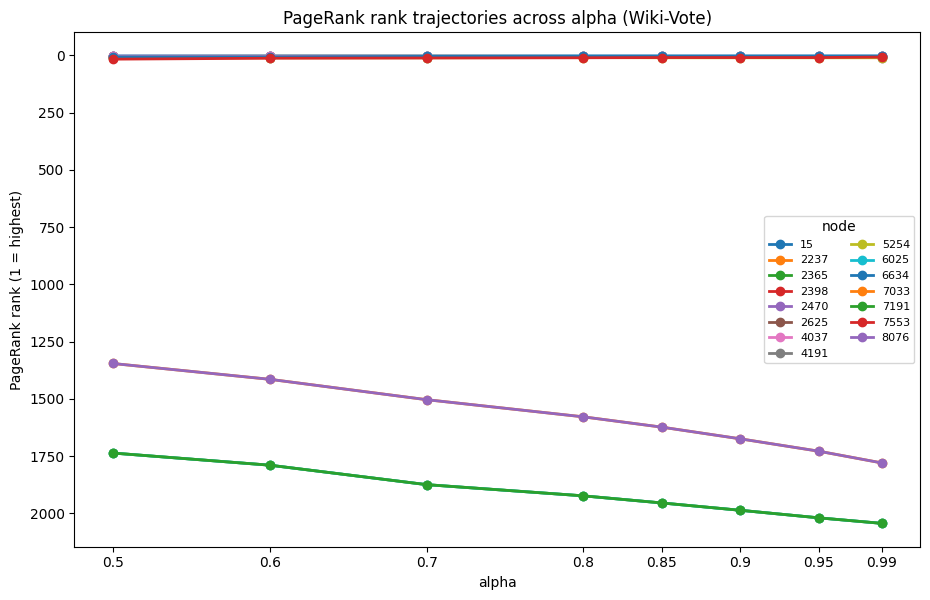

In [4]:
ANOMALY_NODES = []


ALPHAS = np.array([0.50, 0.60, 0.70, 0.80, 0.85, 0.90, 0.95, 0.99], dtype=float)

def scores_to_rank(score_dict: dict[int, float]) -> pd.Series:
    s = pd.Series(score_dict, dtype=float)
    return s.rank(ascending=False, method="min").astype(int)


top10_pr_085 = (
    merged.sort_values("rank_pagerank")
    .head(10)[["node", "pagerank_score", "rank_pagerank"]]
    .copy()
)
top10_pr_085.to_csv(os.path.join(OUT_DIR, "b_top10_pagerank_alpha085.csv"), index=False)

print("Saved: b_top10_pagerank_alpha085.csv")
display(top10_pr_085)

top10_nodes = top10_pr_085["node"].astype(int).tolist()

if len(ANOMALY_NODES) > 0:
    anomaly_nodes = [int(x) for x in ANOMALY_NODES]
else:
    tmp = merged.copy()
    tmp["rank_gap"] = (tmp["rank_authority"] - tmp["rank_pagerank"]).abs()
    anomaly_nodes = tmp.sort_values("rank_gap", ascending=False).head(5)["node"].astype(int).tolist()

tracked_nodes = list(dict.fromkeys(top10_nodes + anomaly_nodes))  # preserve order + unique
print("Tracked nodes (count={}):".format(len(tracked_nodes)), tracked_nodes)


rows = []
for a in ALPHAS:
    pr = nx.pagerank(G, alpha=float(a))
    ranks = scores_to_rank(pr)

    for node in tracked_nodes:
        rows.append({
            "alpha": float(a),
            "node": int(node),
            "pagerank_score": float(pr.get(int(node), np.nan)),
            "pagerank_rank": int(ranks.get(int(node), np.nan)),
        })

traj = pd.DataFrame(rows)

meta = merged[["node", "rank_authority", "rank_pagerank"]].copy()
traj = traj.merge(meta, on="node", how="left")

traj.to_csv(os.path.join(OUT_DIR, "b_rank_trajectories.csv"), index=False)
print("Saved: b_rank_trajectories.csv")
display(traj.head(12))


pivot = traj.pivot_table(index="alpha", columns="node", values="pagerank_rank").sort_index()

plt.figure(figsize=(9.4, 6.1))
for node in pivot.columns:
    plt.plot(pivot.index, pivot[node], marker="o", linewidth=2)

plt.gca().invert_yaxis()
plt.xlabel("alpha")
plt.ylabel("PageRank rank (1 = highest)")
plt.title("PageRank rank trajectories across alpha (Wiki-Vote)")

plt.xticks(ALPHAS, [str(a) for a in ALPHAS])

plt.legend([str(int(n)) for n in pivot.columns], title="node", fontsize=8, ncol=2, frameon=True)

plt.tight_layout()
plt.show()